# AML Marker-Gene Audit — Test Set (1M checkpoint)

Evaluates whether the VAE + diffusion (1M-step training) preserves AML cell-type
identity and immune marker biology in generated single-cell profiles, relative to
matched test-set real cells (van Galen 2019 NanoWell).

**Immune marker panels:** 3 immune-cell types
- **T cell**: CD3D, CD3E, CD8A
- **B cell**: CD19, MS4A1, CD79A
- **Monocyte / Macrophage**: CD14, CD68, LYZ

**Negative controls:** ACTB, HPRT1 (housekeeping; expected to be uniformly expressed).

**Analysis structure**

| # | Section | Visualisation |
|---|---------|---------------|
| 1 | Joint Seurat HVG UMAP | Overall UMAP: real vs generated |
| 2 | Cell-type & sample UMAP | UMAPs of real cells coloured by author cell-type labels |
| 3 | Per-gene expression overlays | UMAPs of immune marker gene expression: real vs generated |
| 4 | Expression distributions | Boxplots of marker gene expression: real (target cell-type vs other) vs generated |
| 5 | Marker-positive cell fraction | Barplots of marker-positive fractions: real vs generated |
| 6 | Global gene mean correlation | Scatter plot of per-gene mean log1p across all cells: real vs generated |

In [11]:
import glob
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
from pathlib import Path
from scipy import sparse

PROJECT_ROOT = Path('/share/home/xiaojied/bulk2scDiff')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from guided_diffusion.cell_datasets_loader import load_VAE, read_preprocessed_adata, read_sample_ids_file

DATA_DIR        = '/share/data/transcriptomics/single cell/curated_mini_umi/AML_vanGalen_2019_NanoWell_AnnData.h5ad'
SAMPLE_IDS_PATH = PROJECT_ROOT / 'output/sample_splits/aml_nocl/test_samples.txt'
GENERATED_GLOB  = str(PROJECT_ROOT / 'output/simulated_samples/aml_pseudobulk_1M_nocl_test_*.npz')
VAE_PATH        = PROJECT_ROOT / 'output/checkpoint/AE/my_VAE_nocl/model_seed=0_step=199999.pt'

SAMPLE_KEY     = 'SampleID'
CELLTYPE_KEY   = 'CellType'   
HIDDEN_DIM     = 128
DECODE_BATCH   = 1024
SEED           = 1234

# UMAP uses Seurat dispersion-based HVG on the full transcriptome
UMAP_PER_SAMPLE = 1000   # cells kept per sample for the UMAP matrices (real and generated separately).
UMAP_N_PCS      = 20     # PCs used in sc.pp.neighbors after HVG -> scale -> PCA
UMAP_N_NBRS     = 10     # k-NN neighbours

# Immune marker panels for AML (3 immune cell types)
IMMUNE_MARKER_PANELS = {
    'T cell':                 ['CD3D', 'CD3E', 'CD8A'],
    'B cell':                 ['CD19', 'MS4A1', 'CD79A'],
    'Monocyte/Macrophage':    ['CD14', 'CD68', 'LYZ'],
}
NEGATIVE_CONTROL_GENES = ['ACTB', 'HPRT1']

# Anything not in these sets is treated as 'Other'.
CELLTYPE_TO_IMMUNE = {}
for _ct in ['CD4_Memory', 'CD4_Naive', 'CD8_Memory', 'CD8_Cytotoxic', 'CD8_Naive',
            'CD4_Treg', 'CD8_Exhausted', 'CD8_Exhausted_prolif', 'CD4_Treg_prolif', 'CD4_Tfh']:
    CELLTYPE_TO_IMMUNE[_ct] = 'T cell'
for _ct in ['B_Immature', 'B_Memory', 'B_Naive', 'Plasma']:
    CELLTYPE_TO_IMMUNE[_ct] = 'B cell'
for _ct in ['CD14_Mono', 'CD16_Mono', 'Macrophage']:
    CELLTYPE_TO_IMMUNE[_ct] = 'Monocyte/Macrophage'

ALL_IMMUNE_GENES  = [g for panel in IMMUNE_MARKER_PANELS.values() for g in panel]
ALL_PANEL_GENES   = ALL_IMMUNE_GENES + NEGATIVE_CONTROL_GENES
GENE_TO_PANEL     = {g: grp for grp, panel in IMMUNE_MARKER_PANELS.items() for g in panel}
for _g in NEGATIVE_CONTROL_GENES:
    GENE_TO_PANEL[_g] = 'neg_control'

SOURCE_COLORS = {'real': '#1976D2', 'generated': '#F4511E'}
ROW_COLORS    = {
    'T cell markers':              '#4CAF50',
    'B cell markers':              '#9C27B0',
    'Monocyte/Macrophage markers': '#FF5722',
    'Neg controls':                '#9E9E9E',
}
IMMUNE_COLORS = {
    'T cell':              '#4CAF50',
    'B cell':              '#9C27B0',
    'Monocyte/Macrophage': '#FF5722',
    'Other':               '#BDBDBD',
}

sc.settings.verbosity = 1
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
print('Configuration loaded.')

Configuration loaded.


In [12]:
def scalar_from_npz(value):
    array = np.asarray(value)
    return array.item() if array.shape == () else array.reshape(-1)[0]


def gather_sparse_rows_and_cols(matrix, row_mask, col_indices):
    view = matrix[row_mask][:, col_indices]
    if sparse.issparse(view):
        view = view.toarray()
    return np.asarray(view, dtype=np.float32)


def decode_marker_columns_with_loaded_vae(latent_data, vae, marker_indices, batch_size, device):
    latent_data = np.asarray(latent_data, dtype=np.float32)
    batches = []
    with torch.no_grad():
        for start in range(0, latent_data.shape[0], batch_size):
            batch = latent_data[start:start + batch_size]
            decoded = vae(torch.from_numpy(batch).to(device), return_decoded=True)
            batches.append(decoded[:, marker_indices].cpu().numpy().astype(np.float32))
    return np.concatenate(batches, axis=0)


def decode_all_genes(latent_data, vae, batch_size, device):
    latent_data = np.asarray(latent_data, dtype=np.float32)
    batches = []
    with torch.no_grad():
        for start in range(0, latent_data.shape[0], batch_size):
            batch = latent_data[start:start + batch_size]
            decoded = vae(torch.from_numpy(batch).to(device), return_decoded=True)
            batches.append(decoded.cpu().numpy().astype(np.float32))
    return np.concatenate(batches, axis=0)


def build_umap_seurat_hvg(matrix, obs, gene_names, n_neighbors=10, n_pcs=20):
    """Build UMAP using Seurat dispersion-based HVG on the joint real+generated pool."""
    mat = np.nan_to_num(np.clip(np.asarray(matrix, dtype=np.float32), -100, 100))
    adata = ad.AnnData(mat)
    adata.var_names = [str(g) for g in gene_names]
    adata.obs = obs.reset_index(drop=True).copy()
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    n_hvg = int(adata.var['highly_variable'].sum())
    adata.raw = adata
    adata = adata[:, adata.var.highly_variable].copy()
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver='arpack')
    sc.pp.neighbors(adata, n_neighbors=n_neighbors,
                    n_pcs=min(n_pcs, adata.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata)
    print(f'  Seurat HVG: {n_hvg} genes -> PCA -> UMAP')
    return adata


print('Helper functions defined.')

Helper functions defined.


In [13]:
# 1. Load real AnnData, filter to test samples
adata = read_preprocessed_adata(DATA_DIR)
sample_values   = adata.obs[SAMPLE_KEY].astype(str).to_numpy()
celltype_values = adata.obs[CELLTYPE_KEY].astype(str).to_numpy() if CELLTYPE_KEY in adata.obs else np.array(['NA'] * adata.n_obs)

allowed_ids = read_sample_ids_file(str(SAMPLE_IDS_PATH))
if allowed_ids is not None:
    keep_mask       = np.isin(sample_values, list(allowed_ids))
    adata           = adata[keep_mask].copy()
    sample_values   = adata.obs[SAMPLE_KEY].astype(str).to_numpy()
    celltype_values = adata.obs[CELLTYPE_KEY].astype(str).to_numpy() if CELLTYPE_KEY in adata.obs else np.array(['NA'] * adata.n_obs)

print(f'Filtered AnnData shape: {adata.shape}')
print('Cell-type counts (top 15):')
print(pd.Series(celltype_values).value_counts().head(15))

# Vectorised mapping CellType -> immune class
immune_class_values = np.array([CELLTYPE_TO_IMMUNE.get(c, 'Other') for c in celltype_values])
print('\nImmune-class counts (mapped from CellType):')
print(pd.Series(immune_class_values).value_counts())

# 2. Map panel genes to AnnData column indices
available_genes    = np.asarray(adata.var_names.astype(str))
gene_to_index      = {gene: idx for idx, gene in enumerate(available_genes)}
all_genes_in_adata = [g for g in ALL_PANEL_GENES if g in gene_to_index]
missing_genes      = [g for g in ALL_PANEL_GENES if g not in gene_to_index]
if missing_genes:
    print(f'WARNING: genes not found in dataset: {missing_genes}')
all_gene_indices = [gene_to_index[g] for g in all_genes_in_adata]

# 3. Locate generated .npz files
generated_paths = sorted(glob.glob(GENERATED_GLOB))
path_by_sample  = {}
for path_str in generated_paths:
    with np.load(path_str, allow_pickle=False) as f:
        sid = str(scalar_from_npz(f['source_sample_id']))
    if allowed_ids is None or sid in allowed_ids:
        path_by_sample[sid] = path_str

# 4. Load VAE
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vae = load_VAE(vae_path=str(VAE_PATH), num_gene=adata.n_vars, hidden_dim=HIDDEN_DIM, device=device)
vae.eval()

# 5. Extract marker genes per sample -> full per-cell arrays
real_cells_list, gen_cells_list = [], []
real_obs_rows,   gen_obs_rows   = [], []

print(f'\nDecoding {len(all_genes_in_adata)} marker genes for {len(path_by_sample)} samples...')
for sample_id, path in sorted(path_by_sample.items()):
    sample_mask = sample_values == sample_id
    if not sample_mask.any():
        print(f'  skipping {sample_id}: not present in real AnnData')
        continue

    with np.load(path, allow_pickle=False) as f:
        generated_latent = np.asarray(f['cell_gen'], dtype=np.float32)

    real_expr = gather_sparse_rows_and_cols(adata.X, sample_mask, all_gene_indices)
    gen_expr  = decode_marker_columns_with_loaded_vae(
        generated_latent, vae, all_gene_indices, DECODE_BATCH, device
    )

    real_cells_list.append(real_expr)
    gen_cells_list.append(gen_expr)

    sample_celltypes      = celltype_values[sample_mask]
    sample_immune_classes = immune_class_values[sample_mask]
    real_obs_rows.extend([
        {'sample_id': sample_id, 'celltype': ct, 'immune_class': ic, 'source': 'real'}
        for ct, ic in zip(sample_celltypes, sample_immune_classes)
    ])
    gen_obs_rows.extend([
        {'sample_id': sample_id, 'celltype': 'generated', 'immune_class': 'generated', 'source': 'generated'}
    ] * len(gen_expr))

    print(f'  {sample_id}: {int(sample_mask.sum())} real, {generated_latent.shape[0]} generated')

real_matrix_full = np.concatenate(real_cells_list, axis=0)
gen_matrix_full  = np.concatenate(gen_cells_list,  axis=0)
real_obs_full    = pd.DataFrame(real_obs_rows)
gen_obs_full     = pd.DataFrame(gen_obs_rows)

print(f'\nMarker-gene analysis data ready.')
print(f'  real: {real_matrix_full.shape},  generated: {gen_matrix_full.shape}')

Filtered AnnData shape: (8146, 19616)
Cell-type counts (top 15):
T            1635
Prog-like    1565
HSC-like      977
HSC           940
Unlabeled     782
Mono-like     424
NK            411
lateEry       199
earlyEry      196
cDC-like      190
CTL           141
Prog          139
Mono          122
GMP-like       86
B              81
dtype: int64

Immune-class counts (mapped from CellType):
Other     8098
B cell      48
dtype: int64

Decoding 11 marker genes for 9 samples...
  AML210A.D0: 719 real, 719 generated
  AML328.D0: 1061 real, 1061 generated
  AML328.D171: 1343 real, 1343 generated
  AML328.D29: 1852 real, 1852 generated
  AML420B.D0: 478 real, 478 generated
  AML475.D29: 101 real, 101 generated
  AML722B.D0: 76 real, 76 generated
  AML916.D0: 928 real, 928 generated
  BM5.34p38n: 1588 real, 1588 generated

Marker-gene analysis data ready.
  real: (8146, 11),  generated: (8146, 11)


In [14]:
# Full-transcriptome matrices for the joint Seurat HVG UMAP.
# Each sample contributes at most UMAP_PER_SAMPLE real and UMAP_PER_SAMPLE generated cells.

rng_umap_fg = np.random.default_rng(SEED + 10)
full_gene_names = list(adata.var_names.astype(str))

_celltype_cols_to_keep = [c for c in ['CellType_Level_0', 'CellType_Level_2', 'CellType_Level_3', CELLTYPE_KEY] if c in adata.obs.columns]

real_umap_fg_blocks, gen_umap_fg_blocks = [], []
real_umap_fg_obs,    gen_umap_fg_obs    = [], []

print(f'Loading full-gene expression for Seurat HVG UMAP ({len(path_by_sample)} samples, \u2264{UMAP_PER_SAMPLE} cells/sample)...')

for sample_id, path in sorted(path_by_sample.items()):
    smask = sample_values == sample_id
    if not smask.any():
        continue

    real_s = adata.X[smask]
    if sparse.issparse(real_s):
        real_s = real_s.toarray()
    real_s = np.asarray(real_s, dtype=np.float32)

    with np.load(path, allow_pickle=False) as f:
        lat_s = np.asarray(f['cell_gen'], dtype=np.float32)
    gen_s = decode_all_genes(lat_s, vae, DECODE_BATCH, device)

    nr = min(real_s.shape[0], UMAP_PER_SAMPLE)
    ng = min(gen_s.shape[0],  UMAP_PER_SAMPLE)
    real_idx = rng_umap_fg.choice(real_s.shape[0], nr, replace=False)
    gen_idx  = rng_umap_fg.choice(gen_s.shape[0],  ng, replace=False)
    real_s   = real_s[real_idx]
    gen_s    = gen_s[gen_idx]

    smask_pos  = np.where(smask)[0]
    global_idx = smask_pos[real_idx]
    for i, gi in enumerate(global_idx):
        row = {'sample_id': sample_id, 'source': 'real'}
        for ct_col in _celltype_cols_to_keep:
            row[ct_col] = str(adata.obs[ct_col].values[gi])
        row['immune_class'] = immune_class_values[gi]
        real_umap_fg_obs.append(row)
    for _ in range(ng):
        row = {'sample_id': sample_id, 'source': 'generated'}
        for ct_col in _celltype_cols_to_keep:
            row[ct_col] = 'generated'
        row['immune_class'] = 'generated'
        gen_umap_fg_obs.append(row)

    real_umap_fg_blocks.append(real_s)
    gen_umap_fg_blocks.append(gen_s)
    print(f'  {sample_id}: {nr} real, {ng} gen  [{adata.n_vars} genes]')

real_matrix_umap_fg = np.concatenate(real_umap_fg_blocks, axis=0)
gen_matrix_umap_fg  = np.concatenate(gen_umap_fg_blocks,  axis=0)
real_obs_umap_fg    = pd.DataFrame(real_umap_fg_obs)
gen_obs_umap_fg     = pd.DataFrame(gen_umap_fg_obs)

print(f'\nFull-gene UMAP matrices ready.')
print(f'  real: {real_matrix_umap_fg.shape},  gen: {gen_matrix_umap_fg.shape}')

Loading full-gene expression for Seurat HVG UMAP (9 samples, ≤1000 cells/sample)...
  AML210A.D0: 719 real, 719 gen  [19616 genes]
  AML328.D0: 1000 real, 1000 gen  [19616 genes]
  AML328.D171: 1000 real, 1000 gen  [19616 genes]
  AML328.D29: 1000 real, 1000 gen  [19616 genes]
  AML420B.D0: 478 real, 478 gen  [19616 genes]
  AML475.D29: 101 real, 101 gen  [19616 genes]
  AML722B.D0: 76 real, 76 gen  [19616 genes]
  AML916.D0: 928 real, 928 gen  [19616 genes]
  BM5.34p38n: 1000 real, 1000 gen  [19616 genes]

Full-gene UMAP matrices ready.
  real: (6302, 19616),  gen: (6302, 19616)


## 1. Joint Seurat HVG UMAP — Source Overview

Embeds real and generated cells jointly in a space constructed from Seurat
dispersion-selected HVGs across the full transcriptome.

Three panels:
- **Real + Generated together** — coloured by source (mixing diagnostic)
- **Real cells only** — coloured by `CellType`
- **Generated cells only** — coloured by `sample_id`

**Pass criterion:** generated cells intermix with real cells; cluster structure in
the generated panel matches the cell-type clusters seen in the real panel.

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


  Seurat HVG: 2709 genes -> PCA -> UMAP
  12604 cells embedded.


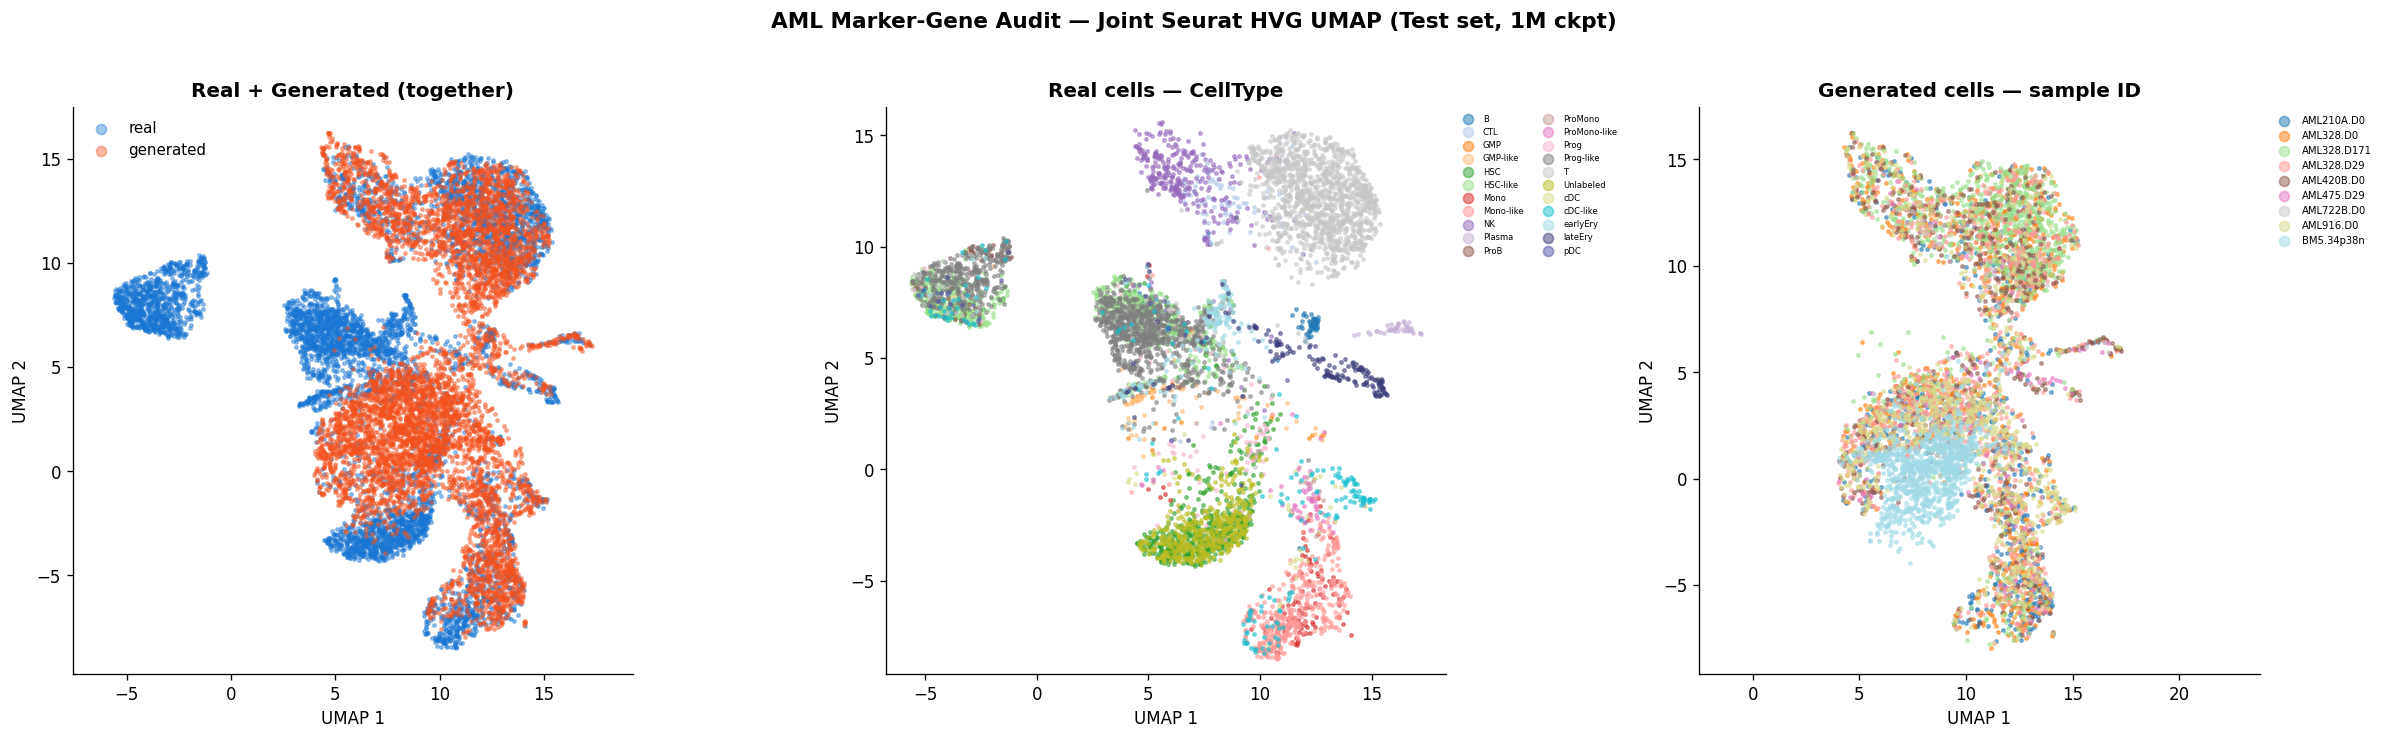

In [15]:
combined_matrix_fg = np.vstack([real_matrix_umap_fg, gen_matrix_umap_fg])
combined_obs_fg = pd.concat(
    [real_obs_umap_fg.assign(source='real'), gen_obs_umap_fg.assign(source='generated')],
    ignore_index=True,
)
combined_obs_fg['source'] = pd.Categorical(combined_obs_fg['source'])

adata_joint = build_umap_seurat_hvg(
    combined_matrix_fg, combined_obs_fg, full_gene_names,
    n_neighbors=UMAP_N_NBRS, n_pcs=UMAP_N_PCS,
)
print(f'  {adata_joint.n_obs} cells embedded.')

coords          = adata_joint.obsm['X_umap']
source_vals     = adata_joint.obs['source'].values
real_mask_joint = source_vals == 'real'
gen_mask_joint  = ~real_mask_joint
coords_real     = coords[real_mask_joint]
coords_gen      = coords[gen_mask_joint]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

_PALETTE = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
_NULL_STRS = {'nan', 'None', 'NaN', 'none', 'NA', 'na', '', 'generated'}

# Panel 1 — source overlay
for label, color in SOURCE_COLORS.items():
    mask = source_vals == label
    axes[0].scatter(coords[mask, 0], coords[mask, 1], c=color, s=4,
                    alpha=0.4, label=label, rasterized=True)
axes[0].set_title('Real + Generated (together)', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=3, fontsize=9, frameon=False)

# Panel 2 — real cells coloured by CellType
ct_real = adata_joint.obs[CELLTYPE_KEY].values[real_mask_joint] if CELLTYPE_KEY in adata_joint.obs.columns else np.array(['NA'] * real_mask_joint.sum())
unique_cts = sorted(set(str(c) for c in ct_real if str(c) not in _NULL_STRS))
ct_cmap = {ct: _PALETTE[i % len(_PALETTE)] for i, ct in enumerate(unique_cts)}
for ct in unique_cts:
    mask = np.array([str(c) == ct for c in ct_real])
    axes[1].scatter(coords_real[mask, 0], coords_real[mask, 1],
                    c=[ct_cmap[ct]], s=4, alpha=0.5, label=ct, rasterized=True)
axes[1].set_title(f'Real cells — {CELLTYPE_KEY}', fontsize=12, fontweight='bold')
axes[1].legend(markerscale=3, fontsize=5, frameon=False,
               loc='upper left', bbox_to_anchor=(1.01, 1),
               ncol=2 if len(unique_cts) > 20 else 1)

# Panel 3 — generated cells coloured by sample_id
sids_gen = adata_joint.obs['sample_id'].values[gen_mask_joint]
unique_sids = sorted(set(sids_gen))
cmap_sid = plt.cm.get_cmap('tab20', max(len(unique_sids), 1))
sid_color = {sid: cmap_sid(i) for i, sid in enumerate(unique_sids)}
for sid in unique_sids:
    mask = sids_gen == sid
    axes[2].scatter(coords_gen[mask, 0], coords_gen[mask, 1],
                    c=[sid_color[sid]], s=4, alpha=0.5, label=sid, rasterized=True)
axes[2].set_title('Generated cells — sample ID', fontsize=12, fontweight='bold')
axes[2].legend(markerscale=3, fontsize=6, frameon=False,
               loc='upper left', bbox_to_anchor=(1.01, 1), ncol=1)

for ax in axes:
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.set_aspect('equal', 'datalim')

fig.suptitle('AML Marker-Gene Audit — Joint Seurat HVG UMAP (Test set, 1M ckpt)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Joint UMAP — Author's Cell-Type Labels

Single panel using the same joint Seurat HVG embedding, coloured by author
cell-type labels (`CellType`) for real cells (generated cells have no
biological label).

**Pass criterion:** distinct cell-type clusters are visible in the real-cell
panel, confirming that the joint embedding preserves biological structure.

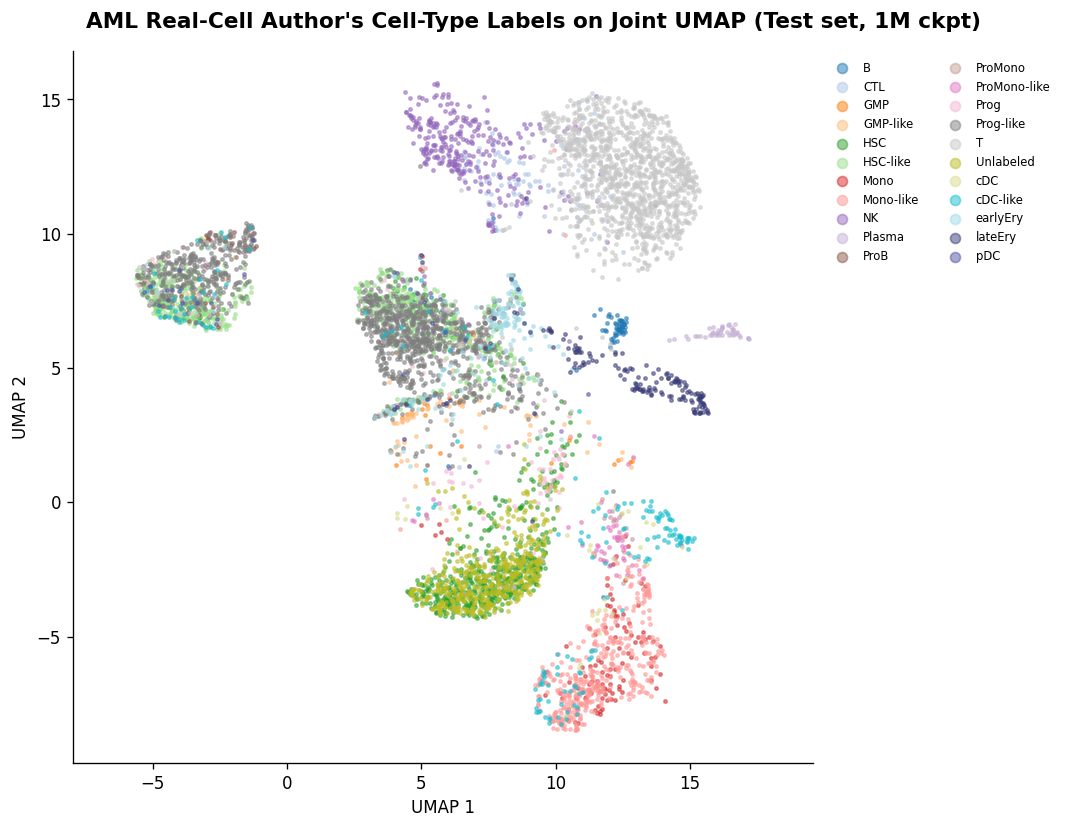

In [16]:
coords          = adata_joint.obsm['X_umap']
source_vals     = adata_joint.obs['source'].values
real_mask_joint = source_vals == 'real'
coords_real     = coords[real_mask_joint]

_PALETTE   = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
_NULL_STRS = {'nan', 'None', 'NaN', 'none', 'NA', 'na', '', 'generated'}

fig, ax = plt.subplots(figsize=(9, 7))

if CELLTYPE_KEY in adata_joint.obs.columns:
    cts    = adata_joint.obs[CELLTYPE_KEY].values[real_mask_joint]
    unique = sorted(set(str(c) for c in cts if str(c) not in _NULL_STRS))
    cmap   = {ct: _PALETTE[i % len(_PALETTE)] for i, ct in enumerate(unique)}
    for ct in unique:
        mask = np.array([str(c) == ct for c in cts])
        ax.scatter(coords_real[mask, 0], coords_real[mask, 1],
                   c=[cmap[ct]], s=4, alpha=0.5, label=ct, rasterized=True)
    ax.legend(markerscale=3, fontsize=7, frameon=False,
              loc='upper left', bbox_to_anchor=(1.01, 1),
              ncol=2 if len(unique) > 20 else 1)
else:
    ax.text(0.5, 0.5, f"'{CELLTYPE_KEY}' not in obs",
            ha='center', va='center', transform=ax.transAxes, fontsize=10)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'datalim')

fig.suptitle("AML Real-Cell Author's Cell-Type Labels on Joint UMAP (Test set, 1M ckpt)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Per-Gene Expression Overlays on Joint UMAP

Renders each immune marker gene + negative control as a log1p colour overlay
(real left, generated right). Colour scale is shared per gene and capped at the
real 99th percentile to prevent rare generated outliers from compressing the
real range.

Rows 1–3: immune-cell type markers (T cell, B cell, Monocyte/Macrophage).
Row 4: negative controls.

**Pass criterion:** high-expression zones in generated panels co-localise with
the same UMAP regions as in real panels. Diffuse or shifted gradients indicate
expression infidelity.

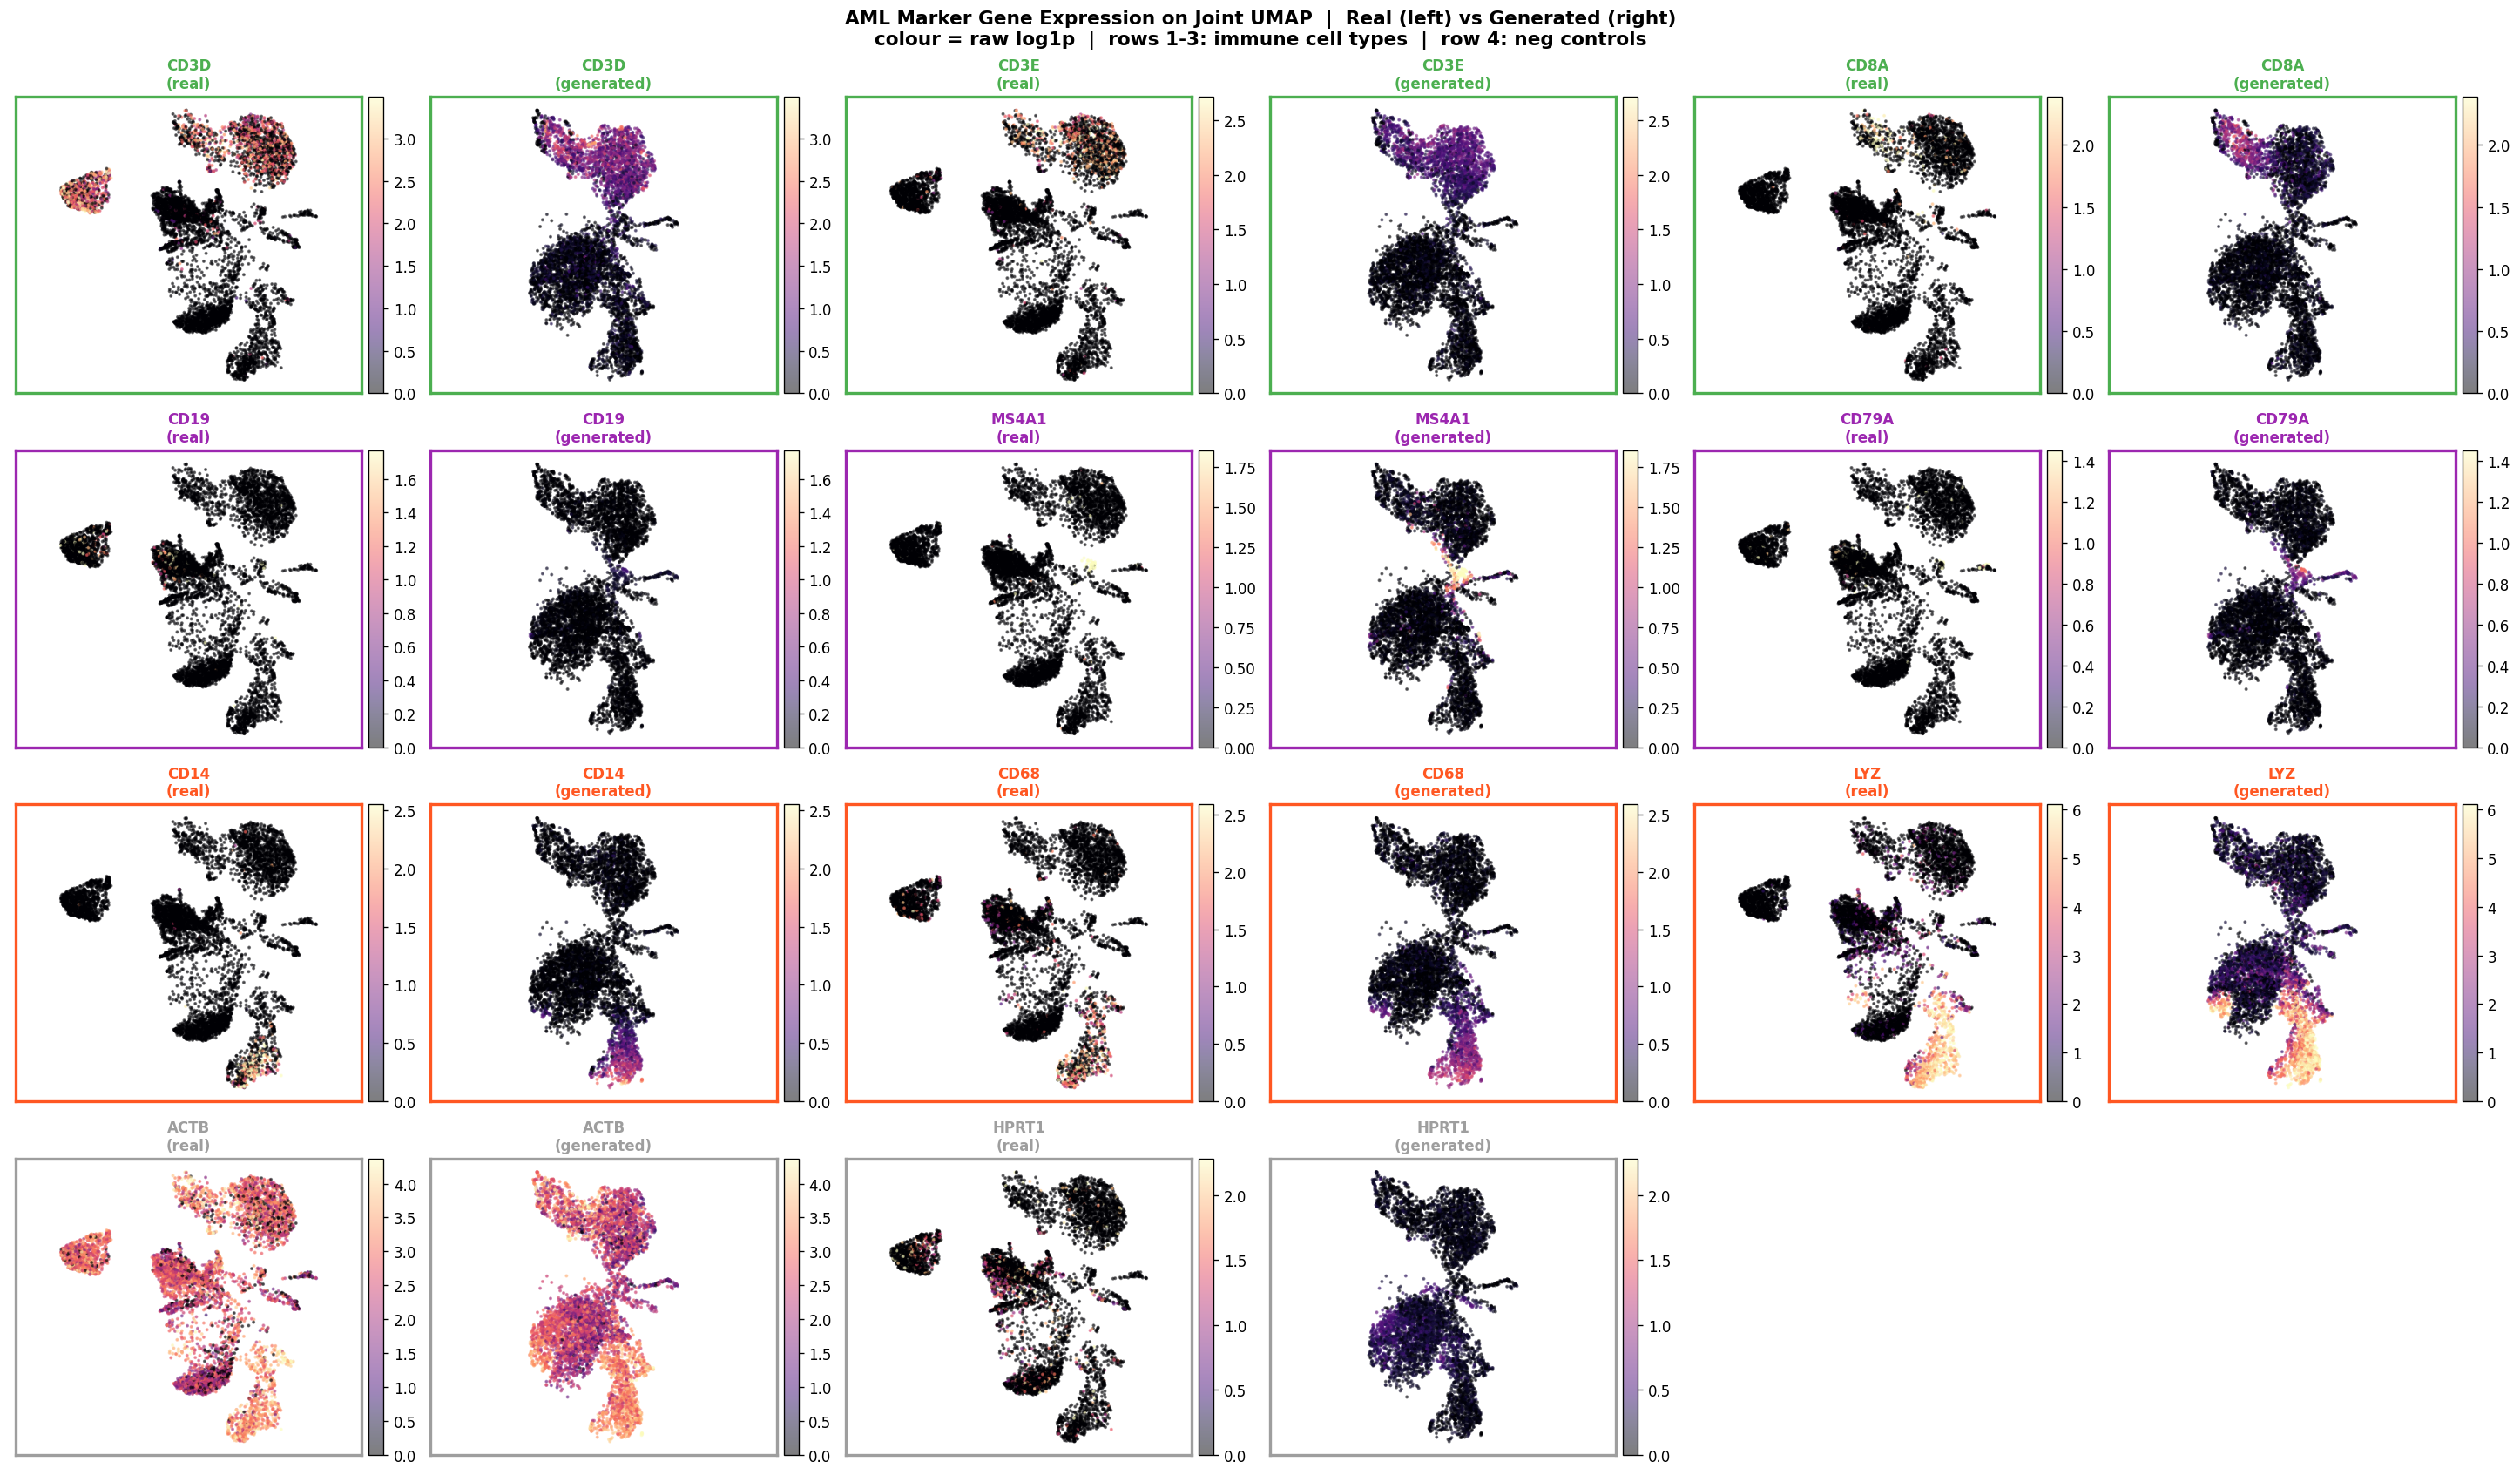

In [17]:
gene_rows = [
    ('T cell markers',              IMMUNE_MARKER_PANELS['T cell']),
    ('B cell markers',              IMMUNE_MARKER_PANELS['B cell']),
    ('Monocyte/Macrophage markers', IMMUNE_MARKER_PANELS['Monocyte/Macrophage']),
    ('Neg controls',                NEGATIVE_CONTROL_GENES),
]

raw_var_names   = list(adata_joint.raw.var_names)
raw_gene_idx    = {g: i for i, g in enumerate(raw_var_names)}
raw_X_src       = adata_joint.raw.X
real_mask_joint = adata_joint.obs['source'].values == 'real'
gen_mask_joint  = ~real_mask_joint
coords_real     = coords[real_mask_joint]
coords_gen      = coords[gen_mask_joint]

marker_expr_cache = {}
for _, genes in gene_rows:
    for gene in genes:
        if gene in raw_gene_idx:
            col = raw_X_src[:, raw_gene_idx[gene]]
            if hasattr(col, 'toarray'):
                col = col.toarray().ravel()
            marker_expr_cache[gene] = np.asarray(col, dtype=np.float32)

n_genes_per_row = max(len(genes) for _, genes in gene_rows)
n_cols = n_genes_per_row * 2
n_rows = len(gene_rows)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), constrained_layout=True)
fig.suptitle(
    'AML Marker Gene Expression on Joint UMAP  |  Real (left) vs Generated (right)\n'
    'colour = raw log1p  |  rows 1-3: immune cell types  |  row 4: neg controls',
    fontsize=13, fontweight='bold',
)

for row_idx, (row_label, genes) in enumerate(gene_rows):
    row_color = ROW_COLORS[row_label]
    for gene_col_idx in range(n_genes_per_row):
        ax_real = axes[row_idx, gene_col_idx * 2]
        ax_gen  = axes[row_idx, gene_col_idx * 2 + 1]

        if gene_col_idx >= len(genes):
            ax_real.set_visible(False)
            ax_gen.set_visible(False)
            continue

        gene = genes[gene_col_idx]
        if gene not in marker_expr_cache:
            ax_real.set_visible(False)
            ax_gen.set_visible(False)
            continue

        expr      = marker_expr_cache[gene]
        expr_real = expr[real_mask_joint]
        expr_gen  = expr[gen_mask_joint]
        vmax = float(np.nanpercentile(expr_real, 99)) or 1.0

        sc_real = ax_real.scatter(
            coords_real[:, 0], coords_real[:, 1], c=expr_real, cmap='magma',
            vmin=0, vmax=vmax, s=2, alpha=0.5, rasterized=True,
        )
        ax_real.set_title(f'{gene}\n(real)', fontsize=10, fontweight='bold', color=row_color)
        ax_real.set_xticks([]); ax_real.set_yticks([])
        ax_real.set_aspect('equal', 'datalim')
        plt.colorbar(sc_real, ax=ax_real, fraction=0.046, pad=0.02)
        for spine in ax_real.spines.values():
            spine.set_edgecolor(row_color); spine.set_linewidth(2.0); spine.set_visible(True)

        sc_gen = ax_gen.scatter(
            coords_gen[:, 0], coords_gen[:, 1], c=expr_gen, cmap='magma',
            vmin=0, vmax=vmax, s=2, alpha=0.5, rasterized=True,
        )
        ax_gen.set_title(f'{gene}\n(generated)', fontsize=10, fontweight='bold', color=row_color)
        ax_gen.set_xticks([]); ax_gen.set_yticks([])
        ax_gen.set_aspect('equal', 'datalim')
        plt.colorbar(sc_gen, ax=ax_gen, fraction=0.046, pad=0.02)
        for spine in ax_gen.spines.values():
            spine.set_edgecolor(row_color); spine.set_linewidth(2.0); spine.set_visible(True)

plt.show()

## 4. Per-Gene Expression Distributions

**Immune markers (9 genes):** four boxes per gene — Real (target immune class)
vs Real (other) vs Generated (all cells). Real cells are split using
`CellType` mapped to the three immune classes. A well-calibrated model
should produce generated-cell expression in a range bracketed by the real
target-class distribution.

**Negative controls (ACTB, HPRT1):** two boxes per gene — Real vs Generated
(all cells). Should be uniformly expressed at comparable levels in real and
generated.

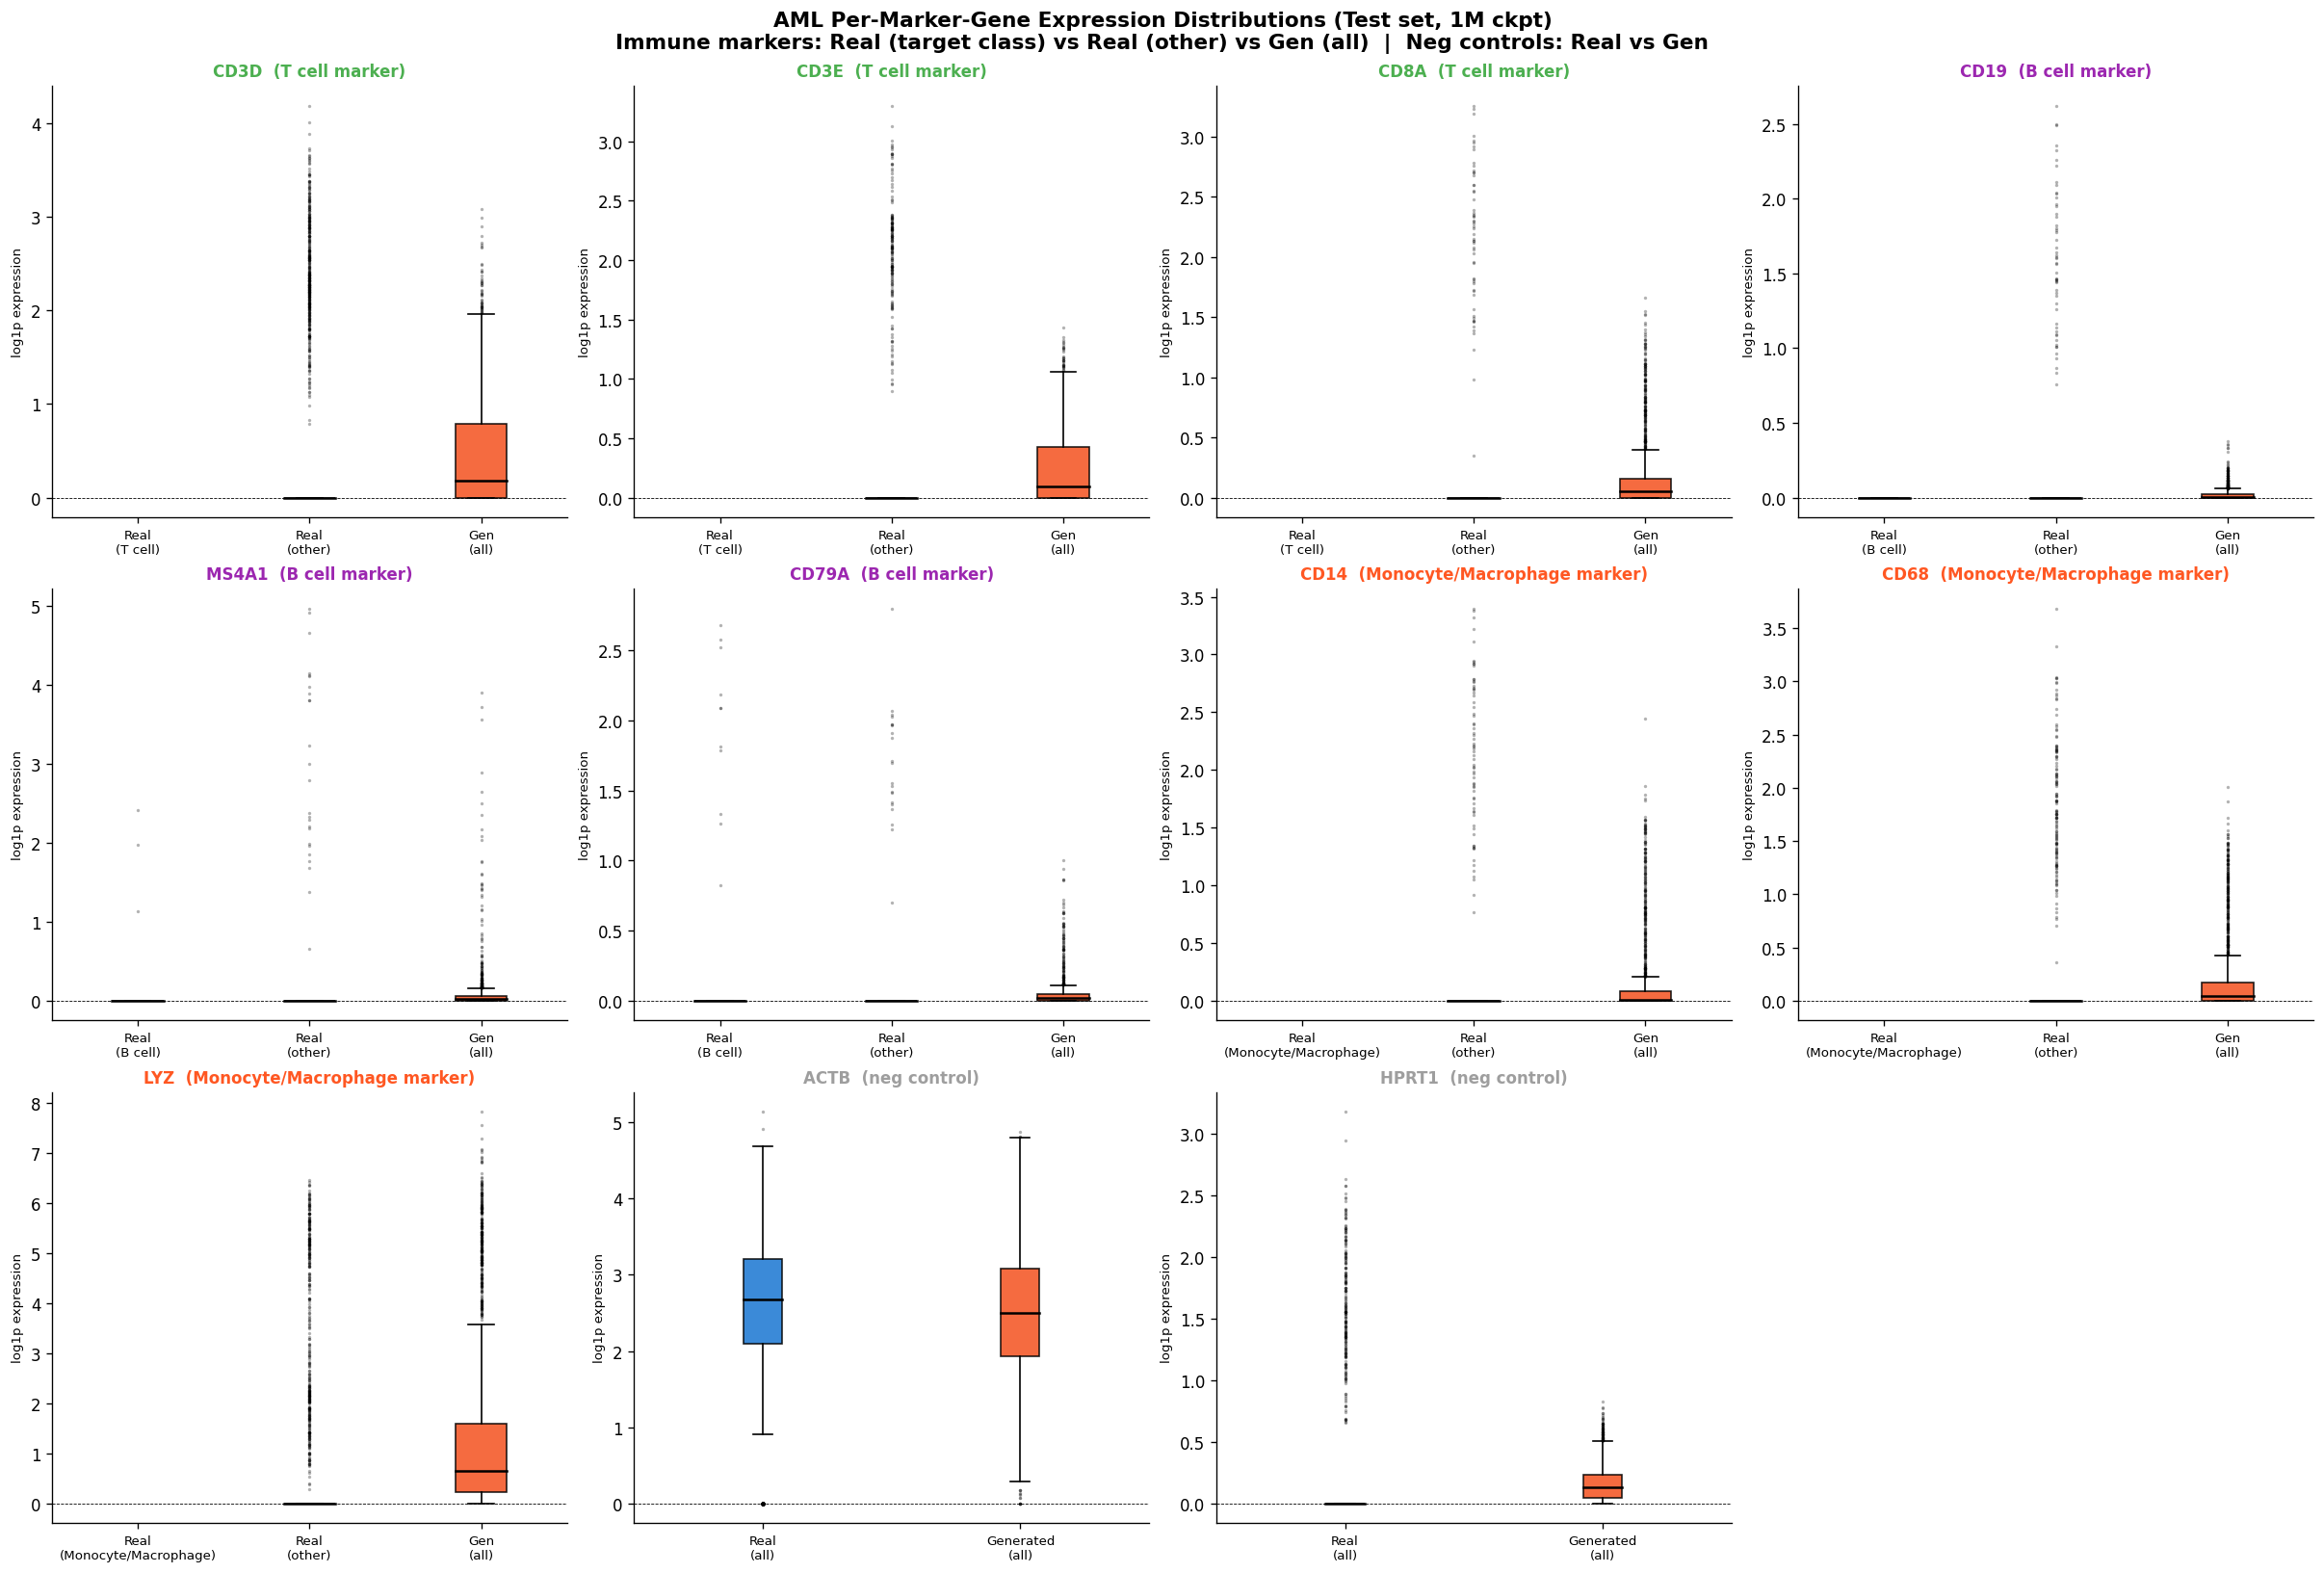

In [18]:
MAX_CELLS_PER_BOX = 2000
rng_box = np.random.default_rng(SEED + 99)

neg_ctrl_set    = set(NEGATIVE_CONTROL_GENES)
all_box_genes   = ALL_IMMUNE_GENES + NEGATIVE_CONTROL_GENES
all_box_genes_present = [g for g in all_box_genes if g in all_genes_in_adata]
n_genes    = len(all_box_genes_present)
n_cols_bp  = 4
n_rows_bp  = (n_genes + n_cols_bp - 1) // n_cols_bp

fig, axes = plt.subplots(n_rows_bp, n_cols_bp,
                         figsize=(5 * n_cols_bp, 4.5 * n_rows_bp),
                         constrained_layout=True)
axes_flat = axes.flatten()

real_immune_arr = real_obs_full['immune_class'].values

def _subsample(matrix, mask, col):
    idx = np.where(mask)[0]
    if len(idx) > MAX_CELLS_PER_BOX:
        idx = rng_box.choice(idx, MAX_CELLS_PER_BOX, replace=False)
    return matrix[idx, col]

for ax_idx, gene in enumerate(all_box_genes_present):
    ax    = axes_flat[ax_idx]
    g_col = all_genes_in_adata.index(gene)

    if gene in neg_ctrl_set:
        all_real = np.ones(real_matrix_full.shape[0], dtype=bool)
        all_gen  = np.ones(gen_matrix_full.shape[0],  dtype=bool)
        data = [
            _subsample(real_matrix_full, all_real, g_col),
            _subsample(gen_matrix_full,  all_gen,  g_col),
        ]
        lbs  = ['Real\n(all)', 'Generated\n(all)']
        clrs = [SOURCE_COLORS['real'], SOURCE_COLORS['generated']]
        title = f'{gene}  (neg control)'
        tcol  = ROW_COLORS['Neg controls']
    else:
        immune_type = GENE_TO_PANEL[gene]
        target_mask = real_immune_arr == immune_type
        other_mask  = ~target_mask
        all_gen     = np.ones(gen_matrix_full.shape[0], dtype=bool)
        data = [
            _subsample(real_matrix_full, target_mask, g_col),
            _subsample(real_matrix_full, other_mask,  g_col),
            _subsample(gen_matrix_full,  all_gen,     g_col),
        ]
        lbs  = [f'Real\n({immune_type})', 'Real\n(other)', 'Gen\n(all)']
        clrs = [IMMUNE_COLORS[immune_type], IMMUNE_COLORS['Other'], SOURCE_COLORS['generated']]
        title = f'{gene}  ({immune_type} marker)'
        tcol  = ROW_COLORS.get(f'{immune_type} markers', '#333333')

    bp = ax.boxplot(
        data, patch_artist=True, notch=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1.0},
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3},
    )
    for patch, color in zip(bp['boxes'], clrs):
        patch.set_facecolor(color); patch.set_alpha(0.85)

    ax.set_xticks(list(range(1, len(lbs) + 1)))
    ax.set_xticklabels(lbs, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold', color=tcol)
    ax.set_ylabel('log1p expression', fontsize=8)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')

for ax_idx in range(n_genes, len(axes_flat)):
    axes_flat[ax_idx].set_visible(False)

fig.suptitle(
    'AML Per-Marker-Gene Expression Distributions (Test set, 1M ckpt)\n'
    'Immune markers: Real (target class) vs Real (other) vs Gen (all)  |  Neg controls: Real vs Gen',
    fontsize=13, fontweight='bold',
)
plt.show()

## 5. Marker-Positive Cell Fraction

For each marker gene, computes the fraction of cells with log1p expression >
`EXPR_THRESHOLD` (default 0.5) in real and generated separately. One bar-chart
panel per immune cell type.

**Diagnostic use:** quantifies whether the model preserves marker detection
rates. A large real–generated gap signals expression collapse or dropout
inflation in the generated cells.

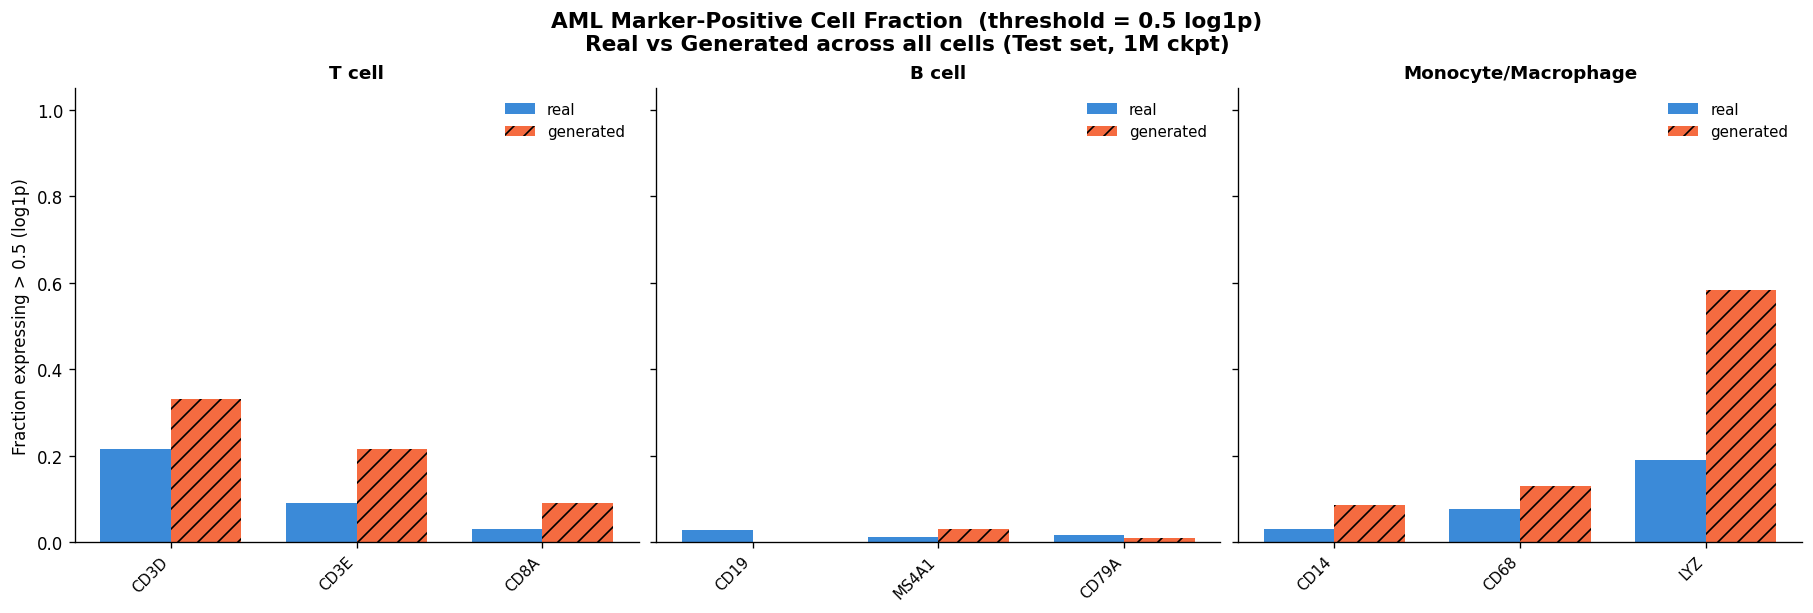

In [19]:
EXPR_THRESHOLD = 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharey=True)
axes_list = axes.flatten().tolist()

for ax_idx, (ax, (category, genes)) in enumerate(zip(axes_list, IMMUNE_MARKER_PANELS.items())):
    genes_present = [g for g in genes if g in all_genes_in_adata]
    missing = [g for g in genes if g not in all_genes_in_adata]
    if missing:
        print(f'WARNING [{category}]: genes not found in dataset, skipping: {missing}')
    if not genes_present:
        ax.text(0.5, 0.5, f'No genes available\nfor {category}',
                ha='center', va='center', transform=ax.transAxes, fontsize=10)
        ax.set_title(category, fontsize=11, fontweight='bold')
        continue

    g_indices  = [all_genes_in_adata.index(g) for g in genes_present]
    real_fracs = [float((real_matrix_full[:, i] > EXPR_THRESHOLD).mean()) for i in g_indices]
    gen_fracs  = [float((gen_matrix_full[:,  i] > EXPR_THRESHOLD).mean()) for i in g_indices]

    x     = np.arange(len(genes_present))
    width = 0.38
    ax.bar(x - width / 2, real_fracs, width,
           color=SOURCE_COLORS['real'], alpha=0.85, label='real')
    ax.bar(x + width / 2, gen_fracs,  width,
           color=SOURCE_COLORS['generated'], alpha=0.85, label='generated', hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(genes_present, rotation=45, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(category, fontsize=11, fontweight='bold')
    if ax_idx == 0:
        ax.set_ylabel(f'Fraction expressing > {EXPR_THRESHOLD} (log1p)')
    ax.legend(fontsize=9, frameon=False)

fig.suptitle(
    f'AML Marker-Positive Cell Fraction  (threshold = {EXPR_THRESHOLD} log1p)\n'
    'Real vs Generated across all cells (Test set, 1M ckpt)',
    fontsize=13, fontweight='bold',
)
plt.show()

## 6. Global Gene Mean Correlation

Per-gene mean log1p expression across all cells (real and generated, drawn from
the full-transcriptome UMAP pool). Reports Pearson r and Spearman ρ; scatter
plot includes a y = x reference line and highlights immune marker genes.

**Diagnostic use:** high r/ρ is necessary but not sufficient — a model that
scales all gene means by a constant factor can achieve high correlation while
distorting relative expression. Inspect the scatter for systematic bias above
or below y = x, and check whether marker genes deviate from the bulk trend.

Pearson r  = 0.9939
Spearman ρ = 0.9748


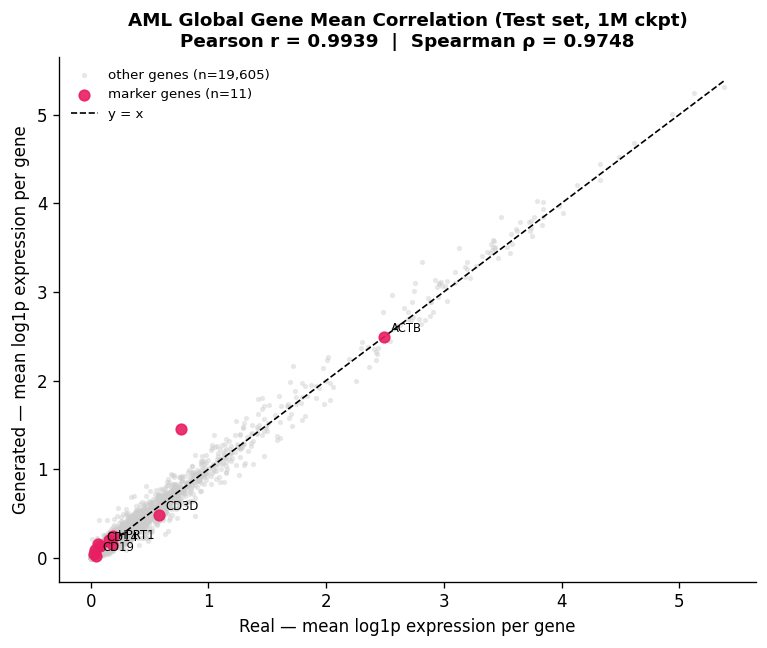

In [20]:
from scipy.stats import pearsonr, spearmanr

def _sparse_safe_mean(mat):
    if sparse.issparse(mat):
        return np.asarray(mat.mean(axis=0)).ravel()
    return np.asarray(mat, dtype=np.float32).mean(axis=0)

real_gene_means = _sparse_safe_mean(real_matrix_umap_fg)
gen_gene_means  = _sparse_safe_mean(gen_matrix_umap_fg)

valid = np.isfinite(real_gene_means) & np.isfinite(gen_gene_means)
r,   _ = pearsonr( real_gene_means[valid], gen_gene_means[valid])
rho, _ = spearmanr(real_gene_means[valid], gen_gene_means[valid])
print(f'Pearson r  = {r:.4f}')
print(f'Spearman \u03c1 = {rho:.4f}')

label_genes = set()
for panel in IMMUNE_MARKER_PANELS.values():
    label_genes.add(panel[0])
label_genes.update(NEGATIVE_CONTROL_GENES)

gene_name_to_umap_idx = {g: i for i, g in enumerate(full_gene_names)}
highlight_genes = [g for g in ALL_PANEL_GENES if g in gene_name_to_umap_idx]
highlight_set   = set(highlight_genes)
highlight_mask  = np.array([g in highlight_set for g in full_gene_names], dtype=bool)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
bg = ~highlight_mask & valid
ax.scatter(real_gene_means[bg], gen_gene_means[bg],
           c='#CCCCCC', s=5, alpha=0.35, rasterized=True,
           label=f'other genes (n={bg.sum():,})')

hi = highlight_mask & valid
ax.scatter(real_gene_means[hi], gen_gene_means[hi],
           c='#E91E63', s=40, alpha=0.9, zorder=5,
           label=f'marker genes (n={hi.sum()})')

for i in np.where(hi)[0]:
    gene = full_gene_names[i]
    if gene in label_genes:
        ax.annotate(gene, (real_gene_means[i], gen_gene_means[i]),
                    fontsize=7, xytext=(4, 3), textcoords='offset points',
                    zorder=6)

lim_min = min(real_gene_means[valid].min(), gen_gene_means[valid].min())
lim_max = max(real_gene_means[valid].max(), gen_gene_means[valid].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1.0, label='y = x')

ax.set_xlabel('Real — mean log1p expression per gene', fontsize=10)
ax.set_ylabel('Generated — mean log1p expression per gene', fontsize=10)
ax.set_title(
    f'AML Global Gene Mean Correlation (Test set, 1M ckpt)\n'
    f'Pearson r = {r:.4f}  |  Spearman \u03c1 = {rho:.4f}',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=8, frameon=False, loc='upper left')
plt.tight_layout()
plt.show()